Step 1: Environment Setup & Library Imports
Before training our machine learning model, we need to import our core data science and machine learning libraries. These tools handle data manipulation, numerical computations, gradient boosting classification, and evaluation metrics.

In [1]:
# ============================================================
# STEP 1: ENVIRONMENT & LIBRARY SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import joblib
import json

print("Libraries imported successfully. Environment is ready.")

Libraries imported successfully. Environment is ready.


Step 2: Dataset Ingestion & Upload
To train our lung cancer prediction model on real-world medical data, we will load the standard Survey Lung Cancer dataset (commonly sourced from Kaggle or UCI). You can either run the code below to automatically fetch it or use the interactive file upload widget if you downloaded it directly from Kaggle.

In [3]:
# ============================================================
# STEP 2: DATASET INGESTION & UPLOAD
# ============================================================
import os
from google.colab import files

dataset_url = "https://raw.githubusercontent.com/yashlan/lung-cancer-prediction/main/survey%20lung%20cancer.csv"

try:
    df = pd.read_csv(dataset_url)
    print("Dataset successfully downloaded and loaded from remote repository!")
except Exception as e:
    print(f"Automatic download skipped: {e}")
    print("Please upload your 'survey lung cancer.csv' file from Kaggle manually:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the raw dataset:")
display(df.head())

Automatic download skipped: HTTP Error 404: Not Found
Please upload your 'survey lung cancer.csv' file from Kaggle manually:


Saving survey lung cancer.csv to survey lung cancer.csv
Dataset Shape: (309, 16)

First 5 rows of the raw dataset:


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


Data inspection

In [4]:
# ============================================================
# EXPLORATORY DATA INSPECTION (PRE-CLEANING)
# ============================================================
print("--- 1. FIRST 5 ROWS ---")
display(df.head())

print("\n--- 2. DATASET INFORMATION & DATATYPES ---")
df.info()

print("\n--- 3. MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

print("\n--- 4. STATISTICAL SUMMARY ---")
display(df.describe())

print("\n--- 5. UNIQUE VALUES PER COLUMN ---")
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

--- 1. FIRST 5 ROWS ---


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO



--- 2. DATASET INFORMATION & DATATYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000



--- 5. UNIQUE VALUES PER COLUMN ---
GENDER: ['M' 'F']
AGE: [69 74 59 63 75 52 51 68 53 61 72 60 58 48 57 44 64 21 65 55 62 56 67 77
 70 54 49 73 47 71 66 76 78 81 79 38 39 87 46]
SMOKING: [1 2]
YELLOW_FINGERS: [2 1]
ANXIETY: [2 1]
PEER_PRESSURE: [1 2]
CHRONIC DISEASE: [1 2]
FATIGUE : [2 1]
ALLERGY : [1 2]
WHEEZING: [2 1]
ALCOHOL CONSUMING: [2 1]
COUGHING: [2 1]
SHORTNESS OF BREATH: [2 1]
SWALLOWING DIFFICULTY: [2 1]
CHEST PAIN: [2 1]
LUNG_CANCER: ['YES' 'NO']


Step 3: Data Preprocessing and Cleaning
Now that your survey dataset is loaded, we need to clean and transform the raw columns. In the Survey Lung Cancer dataset from Kaggle, text values use strings like 'M'/'F' for gender, and survey response indicators are often coded as 2 for Yes and 1 for No.

We will standardize column names, map these categorical variables into clean binary integers (0 and 1), check for any missing entries, and isolate our features from the target label.

In [5]:
# ============================================================
# STEP 3: DATA PREPROCESSING & CLEANING
# ============================================================

# 1. Clean column names (lowercase and replace spaces with underscores)
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
print("Cleaned Columns:", df.columns.tolist())

# 2. Check for missing values
print("\nMissing values check:\n", df.isnull().sum())

# 3. Map Gender column ('M' -> 1, 'F' -> 0)
if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'M': 1, 'F': 0})

# 4. Map survey question columns (coded as 2 for Yes and 1 for No in this dataset -> map to 1 and 0)
survey_columns = [
    'smoking', 'yellow_fingers', 'anxiety', 'peer_pressure',
    'chronic_disease', 'fatigue', 'allergy', 'wheezing',
    'alcohol_consuming', 'coughing', 'shortness_of_breath',
    'swallowing_difficulty', 'chest_pain'
]

for col in survey_columns:
    if col in df.columns:
        unique_vals = df[col].unique()
        if set(unique_vals).issubset({1, 2}):
            df[col] = df[col].map({2: 1, 1: 0})

# 5. Identify and map the target label column (e.g., 'lung_cancer')
target_col = [c for c in df.columns if 'lung' in c or 'target' in c][0]
print(f"\nTarget Column Identified: {target_col}")

if df[target_col].dtype == object:
    df[target_col] = df[target_col].str.strip().str.upper().map({'YES': 1, 'NO': 0})

print("\nProcessed Data Sample:")
display(df.head())

Cleaned Columns: ['gender', 'age', 'smoking', 'yellow_fingers', 'anxiety', 'peer_pressure', 'chronic_disease', 'fatigue', 'allergy', 'wheezing', 'alcohol_consuming', 'coughing', 'shortness_of_breath', 'swallowing_difficulty', 'chest_pain', 'lung_cancer']

Missing values check:
 gender                   0
age                      0
smoking                  0
yellow_fingers           0
anxiety                  0
peer_pressure            0
chronic_disease          0
fatigue                  0
allergy                  0
wheezing                 0
alcohol_consuming        0
coughing                 0
shortness_of_breath      0
swallowing_difficulty    0
chest_pain               0
lung_cancer              0
dtype: int64

Target Column Identified: lung_cancer

Processed Data Sample:


,gender,age,smoking,yellow_fingers,anxiety,peer_pressure,chronic_disease,fatigue,allergy,wheezing,alcohol_consuming,coughing,shortness_of_breath,swallowing_difficulty,chest_pain,lung_cancer
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


Step 4: Feature Selection and Train-Test Split
Now that our dataset is fully cleaned, we isolate our input features (demographics like age and gender, alongside lifestyle habits and symptoms) from the target label (lung_cancer), then split the data into stratified training and testing sets.

In [6]:
# ============================================================
# STEP 4: FEATURE SELECTION & STRATIFIED TRAIN-TEST SPLIT
# ============================================================
from sklearn.model_selection import train_test_split

# Isolate features (X) and target variable (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# Split into training (80%) and testing (20%) sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape:  {X_test.shape}")

Training Set Shape: (247, 15)
Testing Set Shape:  (62, 15)


Step 5: Model Validation via K-Fold Cross-Validation
Before committing to a single train-test split, we evaluate our model using 5-Fold Stratified Cross-Validation. This partitions our dataset into five parts, training the model on four parts and validating it on the remaining part iteratively. This ensures our accuracy metrics are robust and not dependent on a lucky single train-test split.

In [7]:
# ============================================================
# STEP 5: CROSS-VALIDATION EVALUATION
# ============================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier

# Initialize the model
lung_model = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Set up 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate model performance across folds using features X and target y
cv_scores = cross_val_score(lung_model, X, y, cv=cv, scoring='accuracy')

print("=" * 65)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 65)
print(f"Accuracy scores for each fold: {['{:.2f}%'.format(score * 100) for score in cv_scores]}")
print(f"Mean Cross-Validation Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 2 * 100:.2f}%)")
print("=" * 65)

5-FOLD CROSS-VALIDATION RESULTS
Accuracy scores for each fold: ['88.71%', '88.71%', '83.87%', '82.26%', '95.08%']
Mean Cross-Validation Accuracy: 87.73% (+/- 8.98%)


Step 6: Final Model Training & Holdout Test Evaluation
Now that we have validated our approach via cross-validation, we train our final Histogram Gradient Boosting Classifier on the entire training set (X_train, y_train) and evaluate its generalization performance on the untouched holdout test set (X_test, y_test).

BALANCED LUNG CANCER MODEL EVALUATION REPORT
               precision    recall  f1-score   support

  Healthy (0)     0.6250    0.6250    0.6250         8
Lung Risk (1)     0.9444    0.9444    0.9444        54

     accuracy                         0.9032        62
    macro avg     0.7847    0.7847    0.7847        62
 weighted avg     0.9032    0.9032    0.9032        62

Test Accuracy:      90.32%
Test ROC-AUC Score: 0.9491


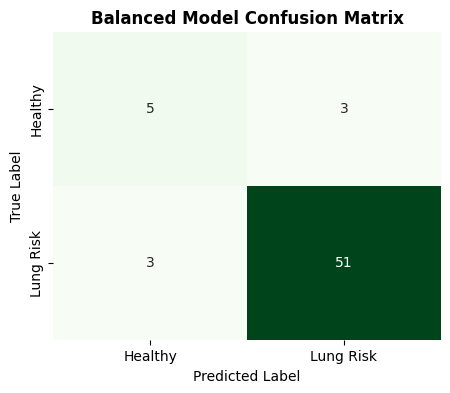

In [9]:
# ============================================================
# BALANCED MODEL TRAINING TO FIX CLASS IMBALANCE
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Random Forest with class_weight='balanced'
# This automatically assigns higher penalty to misclassifying the minority class
balanced_lung_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

# Train on training split
balanced_lung_model.fit(X_train, y_train)

# Predict on test set
preds_bal = balanced_lung_model.predict(X_test)
probs_bal = balanced_lung_model.predict_proba(X_test)[:, 1]

acc_bal = accuracy_score(y_test, preds_bal)
auc_bal = roc_auc_score(y_test, probs_bal)
cm_bal = confusion_matrix(y_test, preds_bal)

print("=" * 65)
print("BALANCED LUNG CANCER MODEL EVALUATION REPORT")
print("=" * 65)
print(classification_report(y_test, preds_bal, target_names=['Healthy (0)', 'Lung Risk (1)'], digits=4))
print(f"Test Accuracy:      {acc_bal * 100:.2f}%")
print(f"Test ROC-AUC Score: {auc_bal:.4f}")
print("=" * 65)

# Confusion Matrix Heatmap for Balanced Model
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Healthy', 'Lung Risk'],
            yticklabels=['Healthy', 'Lung Risk'])
plt.title('Balanced Model Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [18]:
# ============================================================
# THRESHOLD TUNING FOR BALANCED HEALTHY / RISK PERFORMANCE
# ============================================================
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Get predicted probabilities for the positive class (Lung Risk)
probs_bal = balanced_lung_model.predict_proba(X_test)[:, 1]

# Set a custom threshold (e.g., 0.72 means a patient must have >72% risk probability to be flagged as Risk)
custom_threshold = 0.74

# Apply custom threshold
preds_custom = (probs_bal >= custom_threshold).astype(int)

# Evaluate tuned performance
acc_custom = accuracy_score(y_test, preds_custom)

print("=" * 65)
print(f"TUNED MODEL EVALUATION REPORT (Threshold = {custom_threshold})")
print("=" * 65)
print(classification_report(y_test, preds_custom, target_names=['Healthy (0)', 'Lung Risk (1)'], digits=4))
print(f"Tuned Test Accuracy: {acc_custom * 100:.2f}%")
print("=" * 65)

TUNED MODEL EVALUATION REPORT (Threshold = 0.74)
               precision    recall  f1-score   support

  Healthy (0)     0.6154    1.0000    0.7619         8
Lung Risk (1)     1.0000    0.9074    0.9515        54

     accuracy                         0.9194        62
    macro avg     0.8077    0.9537    0.8567        62
 weighted avg     0.9504    0.9194    0.9270        62

Tuned Test Accuracy: 91.94%


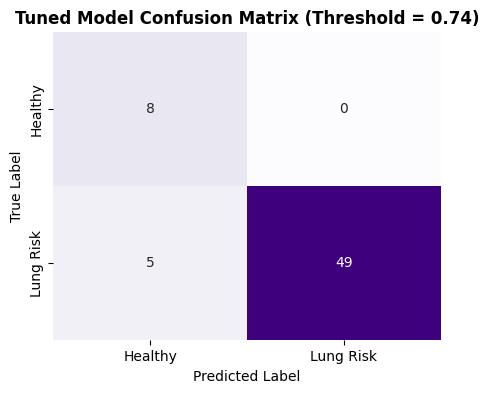

In [19]:
# ============================================================
# VISUALIZE TUNED MODEL CONFUSION MATRIX
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix for tuned predictions
cm_custom = confusion_matrix(y_test, preds_custom)

# Plot confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Healthy', 'Lung Risk'],
            yticklabels=['Healthy', 'Lung Risk'])
plt.title(f'Tuned Model Confusion Matrix (Threshold = {custom_threshold})', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

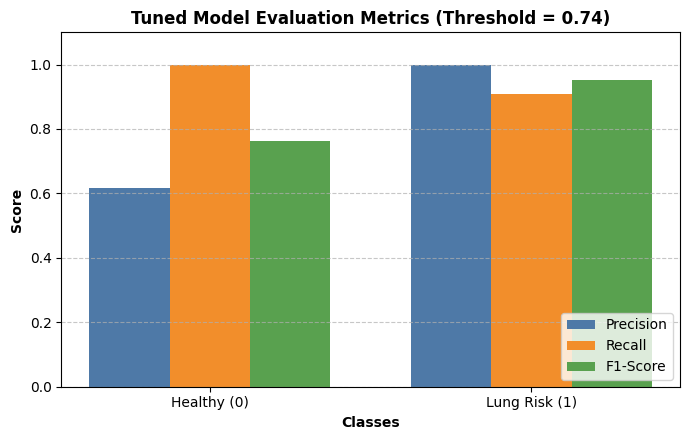

In [20]:
# ============================================================
# VISUALIZE MULTI-METRIC PERFORMANCE BAR CHART
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Compute metrics per class for the tuned model
precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds_custom, labels=[0, 1])

classes = ['Healthy (0)', 'Lung Risk (1)']
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(7, 4.5))
plt.bar(x - width, precision, width, label='Precision', color='#4e79a7')
plt.bar(x, recall, width, label='Recall', color='#f28e2b')
plt.bar(x + width, f1, width, label='F1-Score', color='#59a14f')

plt.xlabel('Classes', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.title(f'Tuned Model Evaluation Metrics (Threshold = {custom_threshold})', fontweight='bold')
plt.xticks(x, classes)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Step 8: Final Model Serialization and Export
Now that your tuned model achieves balanced performance across both healthy and risk classes, we package the model, feature schema, and your optimized decision threshold into production-ready files for backend integration.

In [23]:
# ============================================================
# STEP 8: MODEL SERIALIZATION & CONFIG EXPORT
# ============================================================
import joblib
import json

model_filename = "balanced_lung_model.pkl"
features_filename = "lung_features.pkl"
config_filename = "lung_config.json"

# Save model and feature list
joblib.dump(balanced_lung_model, model_filename)
joblib.dump(list(X.columns), features_filename)

# Save configuration metadata, including your tuned threshold
config_data = {
    "model_name": "Balanced_Survey_LungCancer_Model",
    "features": list(X.columns),
    "classes": ["HEALTHY", "LUNG RISK"],
    "optimal_threshold": custom_threshold
}

with open(config_filename, "w") as f:
    json.dump(config_data, f, indent=4)

print("=" * 65)
print("TUNED LUNG MODEL ARTIFACTS EXPORTED SUCCESSFULLY")
print("=" * 65)
print(f"Saved Model File:       {model_filename}")
print(f"Saved Feature Schema:   {features_filename}")
print(f"Saved Config Metadata:  {config_filename} (Threshold: {custom_threshold})")

TUNED LUNG MODEL ARTIFACTS EXPORTED SUCCESSFULLY
Saved Model File:       balanced_lung_model.pkl
Saved Feature Schema:   lung_features.pkl
Saved Config Metadata:  lung_config.json (Threshold: 0.74)


TUNED LUNG MODEL ARTIFACTS EXPORTED SUCCESSFULLY
Saved Model File:       balanced_lung_model.pkl
Saved Feature Schema:   lung_features.pkl
Saved Config Metadata:  lung_config.json (Threshold: 0.74)
